In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib as jb

In [2]:
BASE_DIR = os.path.dirname(os.getcwd())
print(BASE_DIR)

dataset_path = os.path.join(
    BASE_DIR,
    "farming ml datasets",
    "plant disease.csv"
)
print(dataset_path)

dataset = pd.read_csv(dataset_path)

d:\ML PROJECTS\AgroAqua AI Intelligent Farming and Aquaculture Management System
d:\ML PROJECTS\AgroAqua AI Intelligent Farming and Aquaculture Management System\farming ml datasets\plant disease.csv


In [3]:
dataset

,temperature,humidity,rainfall,soil_pH,disease_present
0,27.483571,33.215053,0.572758,4.975875,1
1,24.308678,36.945005,42.522346,8.165266,0
2,28.238443,34.026189,16.095303,6.316734,1
3,32.615149,41.104180,20.311015,6.164949,0
4,23.829233,51.971785,11.851323,8.482468,0
...,...,...,...,...,...
9995,31.505510,81.939137,22.406822,5.862952,1
9996,15.008275,86.886833,10.503881,4.070539,0
9997,21.473416,81.891770,13.426869,7.101583,0
9998,27.478828,88.567649,9.719659,7.732620,0


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   temperature      10000 non-null  float64
 1   humidity         10000 non-null  float64
 2   rainfall         10000 non-null  float64
 3   soil_pH          10000 non-null  float64
 4   disease_present  10000 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 390.8 KB


In [5]:
print(pd.isnull(dataset).sum())

temperature        0
humidity           0
rainfall           0
soil_pH            0
disease_present    0
dtype: int64


In [6]:
dataset.describe()

,temperature,humidity,rainfall,soil_pH,disease_present
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,25.612191,62.119300,9.807522,6.245855,0.241000
std,5.813841,22.679977,9.852130,1.302465,0.427712
min,5.387999,6.244209,0.000055,4.000075,0.000000
25%,21.815610,40.772925,2.812822,5.122970,0.000000
50%,25.293238,72.211752,6.864898,6.232188,0.000000
75%,28.916048,81.032999,13.442871,7.386377,0.000000
max,56.686495,102.395421,84.654161,8.499875,1.000000


In [7]:
duplicates = dataset.duplicated().sum()
print(f'The number of duplicates is {duplicates}')

The number of duplicates is 0


In [8]:
dataset_shape = dataset.shape
print(f'The dataset shape is {dataset_shape}')

The dataset shape is (10000, 5)


In [9]:
dataset_object_type = dataset.dtypes
print(dataset_object_type)

temperature        float64
humidity           float64
rainfall           float64
soil_pH            float64
disease_present      int64
dtype: object


In [10]:
numeric_columns =  dataset.select_dtypes(include='number').columns
print(numeric_columns)


Index(['temperature', 'humidity', 'rainfall', 'soil_pH', 'disease_present'], dtype='object')


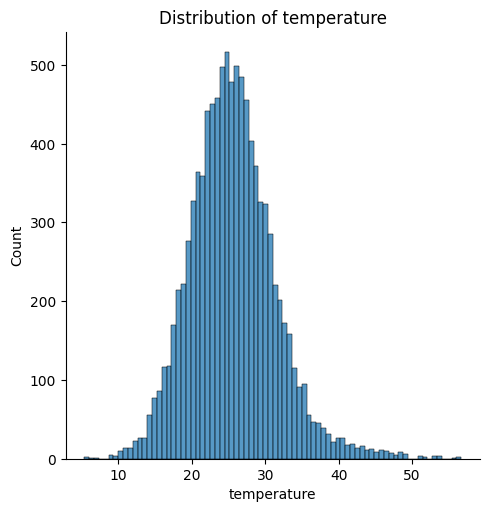

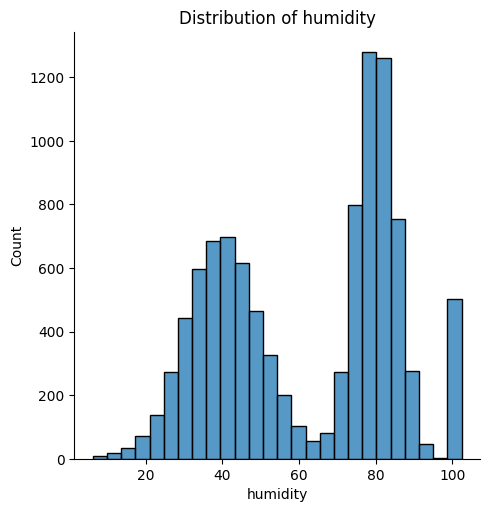

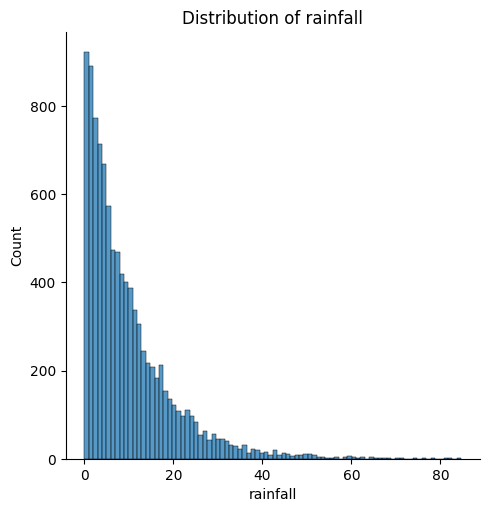

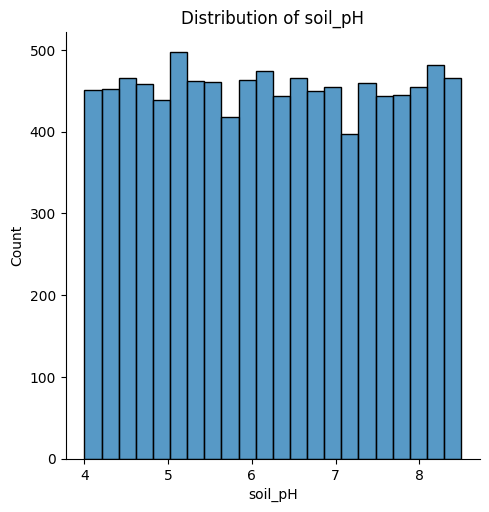

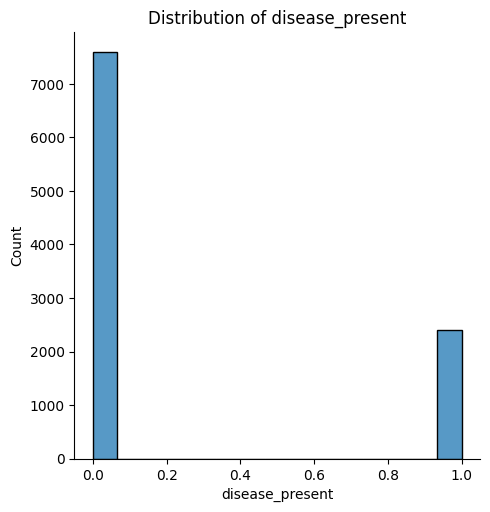

In [11]:
for col in numeric_columns:
    plt.Figure(figsize=(10,10))
    sns.displot(dataset[col])
    plt.title(f'Distribution of {col}')
    plt.show()

In [12]:
categorical_columns = dataset.select_dtypes(include='object').columns
print(categorical_columns)

Index([], dtype='object')


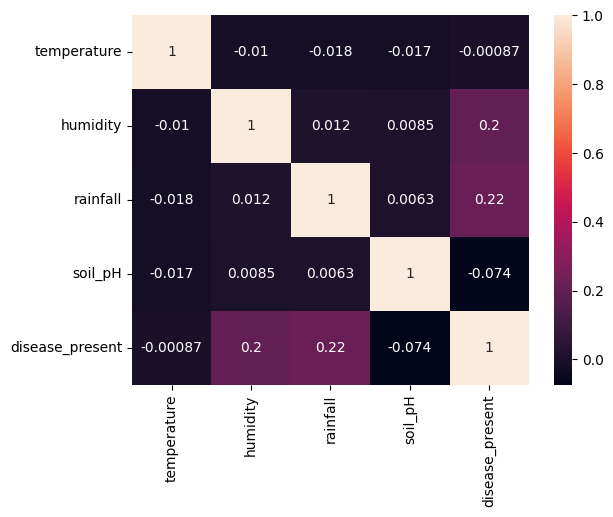

In [13]:
sns.heatmap(dataset[numeric_columns].corr(), annot=True)
plt.show()

In [14]:
x = dataset.drop('disease_present', axis=1)

In [15]:
x

,temperature,humidity,rainfall,soil_pH
0,27.483571,33.215053,0.572758,4.975875
1,24.308678,36.945005,42.522346,8.165266
2,28.238443,34.026189,16.095303,6.316734
3,32.615149,41.104180,20.311015,6.164949
4,23.829233,51.971785,11.851323,8.482468
...,...,...,...,...
9995,31.505510,81.939137,22.406822,5.862952
9996,15.008275,86.886833,10.503881,4.070539
9997,21.473416,81.891770,13.426869,7.101583
9998,27.478828,88.567649,9.719659,7.732620


In [16]:
y = dataset['disease_present']

In [17]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    1
9996    0
9997    0
9998    0
9999    0
Name: disease_present, Length: 10000, dtype: int64

In [18]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [19]:
x_train

,temperature,humidity,rainfall,soil_pH
9254,26.095358,92.061883,5.404683,5.487295
1561,21.263942,28.570575,12.210648,6.187992
1670,23.805340,23.866318,12.913228,4.913851
6087,17.260992,81.205395,2.584584,5.258250
6669,28.513300,79.054710,5.306852,4.611095
...,...,...,...,...
5734,22.129587,87.865680,8.327692,4.815430
5191,24.793537,69.094124,5.666459,6.624904
5390,21.502927,76.827393,14.321883,5.565291
860,26.014615,38.503641,31.488909,6.425853


In [20]:
x_test

,temperature,humidity,rainfall,soil_pH
6252,38.189409,81.236450,1.821797,5.189183
4684,19.814670,32.527782,8.650504,5.983636
1731,23.253416,64.457696,8.218361,4.022305
4742,25.008095,44.829299,2.177695,8.153636
4521,30.371665,41.536491,14.861256,7.288489
...,...,...,...,...
6412,15.981248,90.504936,9.894590,6.089391
8285,29.721926,78.344739,28.912290,5.509029
7853,27.706606,75.979312,13.818873,5.832750
1095,24.596417,46.165794,5.200573,7.683544


In [21]:
y_train

9254    0
1561    0
1670    0
6087    0
6669    0
       ..
5734    0
5191    1
5390    1
860     1
7270    0
Name: disease_present, Length: 8000, dtype: int64

In [22]:
y_test

6252    0
4684    1
1731    0
4742    0
4521    0
       ..
6412    0
8285    1
7853    1
1095    0
6929    1
Name: disease_present, Length: 2000, dtype: int64

In [23]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [24]:
x_train

array([[ 0.07545317,  1.32342119, -0.44562564, -0.5943616 ],
       [-0.75159757, -1.48425785,  0.23656164, -0.05544596],
       [-0.31655639, -1.69228701,  0.30698386, -1.03540537],
       ...,
       [-0.71068756,  0.64972965,  0.44817861, -0.53437413],
       [ 0.06163148, -1.04500306,  2.16889375,  0.12749616],
       [-1.58222364,  0.52263644, -0.24854581,  0.44729671]],
      shape=(8000, 4))

In [25]:
x_test

array([[ 2.14573511,  0.84470461, -0.80475172, -0.8236441 ],
       [-0.99968662, -1.30926433, -0.12028492, -0.21261929],
       [-0.41103567,  0.10272342, -0.16360025, -1.72110607],
       ...,
       [ 0.35126968,  0.61222622,  0.39776   , -0.32866754],
       [-0.18113827, -0.70617139, -0.46608442,  1.09480361],
       [-1.0318645 ,  0.95180511,  0.17401902, -0.63569237]],
      shape=(2000, 4))

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [27]:
models = {
        'Logistic Regression': LogisticRegression(random_state=42),
        'Decision Tree': DecisionTreeClassifier(criterion='entropy', random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=10, criterion = 'entropy', random_state=42),
        'SVM': SVC(kernel='rbf', random_state=42),
        'KNN': KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
    }

In [28]:
trained_models = {}
for model_name, model in models.items():
    print(f'---------- Training {model_name} --------------')
    trained_models[model_name] = model.fit(x_train, y_train)
    print('-------------------------------------------------')

---------- Training Logistic Regression --------------
-------------------------------------------------
---------- Training Decision Tree --------------
-------------------------------------------------
---------- Training Random Forest --------------
-------------------------------------------------
---------- Training SVM --------------
-------------------------------------------------
---------- Training KNN --------------
-------------------------------------------------


In [29]:
test_models = {}
for model_name, model in models.items():
    print(f'----------- Testing {model_name} ----------')
    test_models[model_name] = model.predict(x_test)
    print('------------------------------------------')

----------- Testing Logistic Regression ----------
------------------------------------------
----------- Testing Decision Tree ----------
------------------------------------------
----------- Testing Random Forest ----------
------------------------------------------
----------- Testing SVM ----------
------------------------------------------
----------- Testing KNN ----------
------------------------------------------


In [30]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

training_results = {}

for model_name, model in trained_models.items():
    y_train_pred = model.predict(x_train)

    training_results[model_name] = {
        'accuracy': accuracy_score(y_train, y_train_pred),
        'recall': recall_score(y_train, y_train_pred, average='weighted'),
        'f1': f1_score(y_train, y_train_pred, average='weighted'),
        'precision': precision_score(y_train, y_train_pred, average='weighted')
    }

for i in training_results:
    print(i, training_results[i])

Logistic Regression {'accuracy': 0.76875, 'recall': 0.76875, 'f1': 0.7048788242284902, 'precision': 0.7347141111971873}
Decision Tree {'accuracy': 1.0, 'recall': 1.0, 'f1': 1.0, 'precision': 1.0}
Random Forest {'accuracy': 0.979625, 'recall': 0.979625, 'f1': 0.9793593171758198, 'precision': 0.9799308703188838}
SVM {'accuracy': 0.834375, 'recall': 0.834375, 'f1': 0.8198647196341763, 'precision': 0.8254416647068514}
KNN {'accuracy': 0.86725, 'recall': 0.86725, 'f1': 0.8608182259191828, 'precision': 0.8621307351301594}


In [31]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

testing_results = {}

for model_name, model in trained_models.items():

    y_test_pred = model.predict(x_test)

    testing_results[model_name] = {
        'accuracy': accuracy_score(y_test, y_test_pred),
        'recall': recall_score(y_test, y_test_pred, average='weighted'),
        'f1': f1_score(y_test, y_test_pred, average='weighted'),
        'precision': precision_score(y_test, y_test_pred, average='weighted')
    }

for i in testing_results:
    print(i, testing_results[i])

Logistic Regression {'accuracy': 0.763, 'recall': 0.763, 'f1': 0.6900814929937583, 'precision': 0.7187373074008587}
Decision Tree {'accuracy': 0.782, 'recall': 0.782, 'f1': 0.7823066137508449, 'precision': 0.7826200129382281}
Random Forest {'accuracy': 0.8565, 'recall': 0.8565, 'f1': 0.8465732528865922, 'precision': 0.8508962564192609}
SVM {'accuracy': 0.822, 'recall': 0.822, 'f1': 0.803959016858532, 'precision': 0.8106081395348838}
KNN {'accuracy': 0.8325, 'recall': 0.8325, 'f1': 0.8214900552310173, 'precision': 0.8225253331810696}


In [32]:
final_model = trained_models['KNN']

In [33]:
y_pred = final_model.predict(x_test)

In [34]:
y_pred

array([1, 0, 0, ..., 1, 0, 0], shape=(2000,))

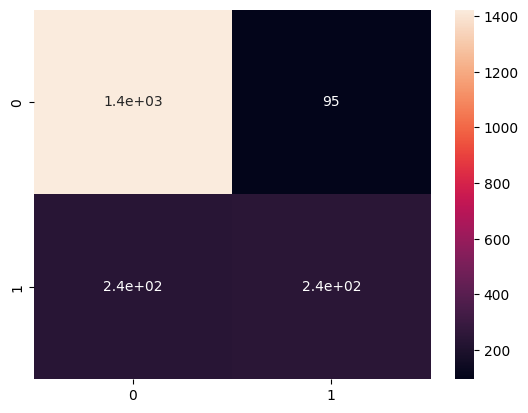

In [35]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)
plt.show()

In [36]:
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.86      0.94      0.89      1518
           1       0.72      0.50      0.59       482

    accuracy                           0.83      2000
   macro avg       0.79      0.72      0.74      2000
weighted avg       0.82      0.83      0.82      2000



In [37]:
from sklearn.model_selection import cross_val_score
cv = cross_val_score(estimator=final_model, X=x_train, y=y_train, cv=10)
print(cv.std())
print(cv.mean())

0.013749999999999978
0.83125


In [38]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f'The accuracy of the model is {round(accuracy, 2)*100}')

The accuracy of the model is 83.0


In [39]:
best_model = trained_models['KNN']
jb.dump(best_model, 'plant_disease_model.joblib')
jb.dump(sc, 'plant_disease_scaler.joblib')

['plant_disease_scaler.joblib']